In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Load the dataset 



In [8]:
data = pd.read_csv('ventas_ml_clase2.csv')
display(data.head())


,marketing,precio,temporada,tienda,canal,ventas
0,5548.49,25.74,2,Sur,Tienda,461.70
1,3128.03,31.60,3,Occidente,Tienda,229.12
2,6350.81,37.94,3,Centro,Tienda,397.16
3,6693.02,34.28,3,Norte,Tienda,458.31
4,1488.14,30.45,1,Occidente,Tienda,197.70


In [9]:
print("""
Filas: {}, Columnas: {}
""".format(data.shape[0], data.shape[1]))

print("""Tipos de datos:
{}
""".format(data.dtypes))    


Filas: 1200, Columnas: 6

Tipos de datos:
marketing    float64
precio       float64
temporada      int64
tienda        object
canal         object
ventas       float64
dtype: object



In [10]:
data.describe(include='all').transpose().head()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marketing,1200.0,NaN,NaN,NaN,4961.787167,1768.35789,0.0,3772.115,5006.215,6107.785,10721.94
precio,1200.0,NaN,NaN,NaN,34.560042,7.154758,13.55,29.915,34.91,39.245,55.4
temporada,1200.0,NaN,NaN,NaN,2.5125,1.112449,1.0,2.0,3.0,3.0,4.0
tienda,1200,5,Norte,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1200,3,Tienda,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Predecir las ventaas usando vaiables precio y temporada, tienda, canal
X = data[['marketing', 'precio', 'temporada', 'tienda', 'canal']]  # Features
y = data['ventas']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño del conjunto de entrenamiento: {}, Tamaño del conjunto de prueba: {} \n Porcentaje de prueba: {:.2f}%".format(X_train.shape[0], X_test.shape[0], (X_test.shape[0] / X.shape[0]) * 100))


# Define the preprocessing for categorical features
categorical_features = ['temporada', 'tienda', 'canal']
categorical_transformer = OneHotEncoder(drop='first')
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'  # Keep the 'precio' column as is
)
# Create a pipeline that combines preprocessing and the regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# Train the model
pipeline.fit(X_train, y_train)
# Make predictions
y_pred = pipeline.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f"="*50)
print(f"Media de las ventas reales: {y_test.mean():.2f}")
print(f"Media de las ventas predichas: {y_pred.mean():.2f}")
print(f"Error relativo (MAE / Media de las ventas reales): {mae / y_test.mean():.2%}")
print(f"="*50)
print("\nCoeficientes del modelo:")
print("Intercepto:", pipeline.named_steps['regressor'].intercept_)
print("Coeficientes:", pipeline.named_steps['regressor'].coef_)
print(f"="*50)
print(f"Interpretaión de las metricas:")
print(f"- El Mean Squared Error (MSE) de {mse:.2f} indica que, en promedio, las predicciones del modelo se desvían de los valores reales en aproximadamente {mse:.2f} unidades cuadradas. Un MSE más bajo indica un mejor ajuste del modelo a los datos.")
print(f"- El R^2 Score de {r2:.2f} sugiere que el modelo explica aproximadamente el {r2:.2%} de la variabilidad en las ventas. Un R^2 cercano a 1 indica un modelo que se ajusta bien a los datos, mientras que un R^2 cercano a 0 indica un modelo que no explica la variabilidad de los datos.")
print(f"- El Mean Absolute Error (MAE) de {mae:.2f} indica que, en promedio, las predicciones del modelo se desvían de los valores reales en aproximadamente {mae:.2f} unidades. Un MAE más bajo indica un mejor ajuste del modelo a los datos.")
print(f"el {(1-r2)*100:.2f}% de la variabilidad en las ventas no es explicada por el modelo, lo que sugiere que hay otros factores no incluidos en el modelo que podrían estar influyendo en las ventas.")

if r2 >= 0.8:
    print("Valoracion: buen ajuste para un modelo lineal")
elif r2 >= 0.5:
    print("Valoracion: ajuste moderado para un modelo lineal")
else:
    print("Valoracion: ajuste pobre para un modelo lineal")

pipeline


Tamaño del conjunto de entrenamiento: 960, Tamaño del conjunto de prueba: 240 
 Porcentaje de prueba: 20.00%
Mean Squared Error: 2024.92
R^2 Score: 0.66
Mean Absolute Error: 36.14
Media de las ventas reales: 386.94
Media de las ventas predichas: 388.56
Error relativo (MAE / Media de las ventas reales): 9.34%

Coeficientes del modelo:
Intercepto: 390.3783973886699
Coeficientes: [ 4.23591432e+01  7.70457765e+01  1.10697105e+02  2.79609738e+01
 -3.38672317e+01 -5.97148063e+01 -2.96227544e+01 -3.59865269e+01
 -7.23983832e+01  1.55632334e-02 -2.08426956e+00]
Interpretaión de las metricas:
- El Mean Squared Error (MSE) de 2024.92 indica que, en promedio, las predicciones del modelo se desvían de los valores reales en aproximadamente 2024.92 unidades cuadradas. Un MSE más bajo indica un mejor ajuste del modelo a los datos.
- El R^2 Score de 0.66 sugiere que el modelo explica aproximadamente el 65.74% de la variabilidad en las ventas. Un R^2 cercano a 1 indica un modelo que se ajusta bien a lo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

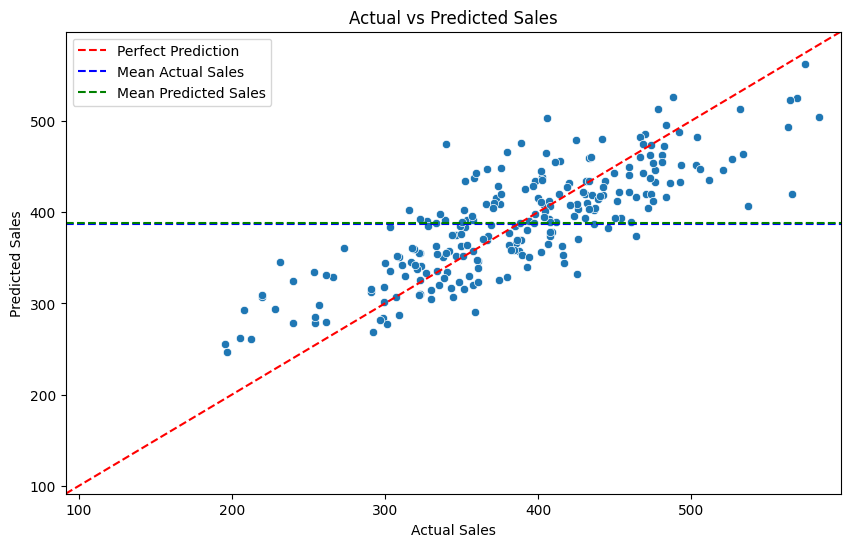

In [31]:

# draw the regression line 
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Prediction')  # Add a reference line for perfect predictions
# Limit the axes to the range of actual values for better visualization
plt.xlim(y.min(), y.max())
plt.ylim(y.min(), y.max())
# set median and mean lines
plt.axhline(y=y_test.mean(), color='blue', linestyle='--', label='Mean Actual Sales')
plt.axhline(y=y_pred.mean(), color='green', linestyle='--', label='Mean Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

# Coeficientes del modelo: ¿que variables pesan más?

Un modelo de regresion lineal es una formula de  ***Sumas ponderadas***

ventas = base + (peso1 x marketing) + (peso2 * precio) + (peso3 * temporada) + ....



In [46]:
# Extract los coeficientes (peso) que el modelo aprendió para cada variable
coeficientes = pipeline.named_steps['regressor'].coef_
print("\nCoeficientes del modelo:")
print("Intercepto:", pipeline.named_steps['regressor'].intercept_)

# Obtener los nombres de las características después del OneHotEncoding
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
feature_names = ohe.get_feature_names_out(categorical_features)
print("Nombres de las características después del OneHotEncoding:")
print(feature_names)

# Los coeficientes corresponden a las características en el siguiente orden:
# ['temporada_primavera', 'temporada_verano', 'temporada_otono', 'tienda_Tienda B', 'tienda_Tienda C', 'canal_Online', 'precio']
print("Coeficientes correspondientes a cada característica:")
for feature, coef in zip(feature_names, coeficientes[:-1]):
    print(f"{feature}: {coef:.4f}")



Coeficientes del modelo:
Intercepto: 390.3783973886699
Nombres de las características después del OneHotEncoding:
['temporada_2' 'temporada_3' 'temporada_4' 'tienda_Norte'
 'tienda_Occidente' 'tienda_Oriente' 'tienda_Sur' 'canal_Online'
 'canal_Tienda']
Coeficientes correspondientes a cada característica:
temporada_2: 42.3591
temporada_3: 77.0458
temporada_4: 110.6971
tienda_Norte: 27.9610
tienda_Occidente: -33.8672
tienda_Oriente: -59.7148
tienda_Sur: -29.6228
canal_Online: -35.9865
canal_Tienda: -72.3984


In [53]:
row = X_test.iloc[[0]].copy()  # Selecciona la primera fila del conjunto de prueba
pred_base = float(pipeline.predict(row)[0])
row_more_marketing = row.copy()
row_more_marketing['marketing'] += float(row_more_marketing['marketing'].values[0]) * 1.1

pred_more_marketing = float(pipeline.predict(row_more_marketing)[0])  # Incrementa el gasto en marketing en un 10% y predice nuevamente

# Calcular la diferencia en la predicción
mkt_original = row['marketing'].values[0]
mkt_nuevo = row_more_marketing['marketing'].values[0]
diferencia_prediccion = pred_more_marketing - pred_base
print(f"\nPredicción original: {pred_base:.2f}")
print(f"Predicción con marketing incrementado: {pred_more_marketing:.2f}")
print(f"Diferencia en la predicción: {diferencia_prediccion:.2f}")
print(f"\nEfecto del incremento en marketing: {diferencia_prediccion:.2f} unidades de ventas adicionales por cada {mkt_nuevo - mkt_original:.2f} unidades de incremento en marketing.")


Predicción original: 445.94
Predicción con marketing incrementado: 542.82
Diferencia en la predicción: 96.88

Efecto del incremento en marketing: 96.88 unidades de ventas adicionales por cada 6225.10 unidades de incremento en marketing.


In [49]:
row = X_test.iloc[[0]].copy()  # Selecciona la primera fila del conjunto de prueba
print("\nFila seleccionada para la predicción:")
print(row)
prediccion = pipeline.predict(row)
print(f"\nPredicción para la fila seleccionada: {prediccion[0]:.2f}")


Fila seleccionada para la predicción:
      marketing  precio  temporada  tienda   canal
1178    5659.18    35.3          3  Centro  Online

Predicción para la fila seleccionada: 445.94
